# NOTEBOOK 01 — DATA UNDERSTANDING
## Global Climate Change — Berkeley Earth Surface Temperature

### Mục tiêu
Notebook này trả lời bốn câu hỏi:

1. Dữ liệu đang có là gì?
2. Dữ liệu có đáng tin cậy không?
3. Các bảng có grain, khóa và quan hệ như thế nào?
4. Cần chuẩn bị gì cho PostgreSQL, Cleaning, EDA, Feature Engineering và Modeling?

### Phạm vi bài toán
Dự án chốt phạm vi:

> **Dự báo nhiệt độ trung bình theo tháng tại 5 thành phố lớn Tokyo, New York, London, Paris và Sydney trong 20 năm tiếp theo.**

- Target: `AverageTemperature`
- Loại bài toán: **Regression + Time-Series Forecasting**
- Dữ liệu lịch sử: >100 năm
- Yêu cầu đặc thù: interpolation để lấp gap, đánh giá xu hướng nóng lên, triển khai thành web app.

## I. Cấu hình project và thư viện

In [12]:
from pathlib import Path
import os

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
ARTIFACTS = PROJECT_ROOT / "artifacts"
APP_DIR = PROJECT_ROOT / "app"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)
APP_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = C:\Global Climate Change


In [13]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)

FILES = {
    "global": DATA_RAW / "GlobalTemperatures.csv",
    "country": DATA_RAW / "GlobalLandTemperaturesByCountry.csv",
    "state": DATA_RAW / "GlobalLandTemperaturesByState.csv",
    "city": DATA_RAW / "GlobalLandTemperaturesByCity.csv",
    "major_city": DATA_RAW / "GlobalLandTemperaturesByMajorCity.csv",
}

missing_files = [str(p) for p in FILES.values() if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Hãy đặt 5 CSV Berkeley Earth vào data/raw. Còn thiếu:\n"
        + "\n".join(missing_files)
    )

TARGET = "AverageTemperature"
TARGET_CITIES = ["Tokyo", "New York", "London", "Paris", "Sydney"]

## II. Dataset Overview, Data Dictionary và Grain

Bộ dữ liệu gồm 5 nguồn với mức chi tiết khác nhau. Không được join trực tiếp tất cả theo `dt` vì có nguy cơ N–N và nhân dòng.

| File | Grain | Vai trò |
|---|---|---|
| GlobalTemperatures | 1 tháng toàn cầu | Context toàn cầu |
| ByCountry | 1 quốc gia × 1 tháng | Context quốc gia |
| ByState | 1 bang/tỉnh × 1 tháng | Bảng phụ, cần aggregate |
| ByCity | 1 thành phố × 1 tháng | Bảng lớn, cần aggregate |
| ByMajorCity | 1 thành phố lớn × 1 tháng | **Main/Fact table** |

### Main table
`GlobalLandTemperaturesByMajorCity.csv`

### Grain
**1 dòng = nhiệt độ của 1 thành phố lớn trong 1 tháng.**

### Business key dự kiến
`dt + City + Country`

In [14]:
data_dictionary = pd.DataFrame([
    ["dt", "Tháng quan sát", "date"],
    ["AverageTemperature", "Nhiệt độ trung bình (°C)", "target"],
    ["AverageTemperatureUncertainty", "Độ bất định nhiệt độ (°C)", "quality"],
    ["City", "Thành phố", "category"],
    ["Country", "Quốc gia", "category"],
    ["Latitude", "Vĩ độ dạng chuỗi, ví dụ 35.68N", "location"],
    ["Longitude", "Kinh độ dạng chuỗi, ví dụ 139.23E", "location"],
], columns=["Column", "Meaning", "Role"])
display(data_dictionary)

,Column,Meaning,Role
0,dt,Tháng quan sát,date
1,AverageTemperature,Nhiệt độ trung bình (°C),target
2,AverageTemperatureUncertainty,Độ bất định nhiệt độ (°C),quality
3,City,Thành phố,category
4,Country,Quốc gia,category
5,Latitude,"Vĩ độ dạng chuỗi, ví dụ 35.68N",location
6,Longitude,"Kinh độ dạng chuỗi, ví dụ 139.23E",location


## III. Profiling 5 CSV theo chunksize

Đề bài yêu cầu tối ưu bộ nhớ khi làm việc với bảng hàng triệu dòng.  
Vì vậy không nạp đồng thời 5 file vào RAM. Hàm dưới đọc theo chunk để lấy:

- số dòng,
- dung lượng file,
- số ô missing,
- sample nhỏ để khảo sát dtype và cấu trúc.

In [ ]:
def profile_csv(path: Path, chunksize=250_000, sample_rows=30_000):
    total_rows = 0
    missing = None
    sample_parts = []
    remain = sample_rows

    for chunk in pd.read_csv(path, chunksize=chunksize):
        total_rows += len(chunk)
        cur = chunk.isna().sum()
        missing = cur if missing is None else missing.add(cur, fill_value=0)

        if remain > 0:
            take = min(remain, len(chunk))
            sample_parts.append(chunk.head(take))
            remain -= take

        del chunk
        gc.collect()

    sample = pd.concat(sample_parts, ignore_index=True) if sample_parts else pd.DataFrame()

    return {
        "file": path.name,
        "rows": total_rows,
        "columns": len(sample.columns),
        "file_size_mb": round(path.stat().st_size / 1024**2, 2),
        "sample_memory_mb": round(sample.memory_usage(deep=True).sum() / 1024**2, 2),
        "missing_cells": int(missing.sum()) if missing is not None else 0,
    }, sample, missing.astype("int64")

profiles, samples, missing_stats = [], {}, {}

for name, path in FILES.items():
    p, sample, miss = profile_csv(path)
    profiles.append(p)
    samples[name] = sample
    missing_stats[name] = miss

profile_df = pd.DataFrame(profiles).sort_values("rows", ascending=False)
display(profile_df)

## IV. Khảo sát sâu bảng chính

In [ ]:
main = pd.read_csv(FILES["major_city"], parse_dates=["dt"])

print("Shape:", main.shape)
display(main.head())
main.info()

print("\nNumeric describe:")
display(main.select_dtypes(include=np.number).describe().T)

print("\nUnique summary:")
unique_summary = pd.DataFrame({
    "nunique": main.nunique(dropna=False),
    "unique_ratio": main.nunique(dropna=False) / len(main)
}).sort_values("unique_ratio", ascending=False)
display(unique_summary)

Shape: (239177, 7)


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W
2,1849-03-01,28.101,1.612,Abidjan,Côte D'Ivoire,5.63N,3.23W
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W


<class 'pandas.DataFrame'>
RangeIndex: 239177 entries, 0 to 239176
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   dt                             239177 non-null  datetime64[us]
 1   AverageTemperature             228175 non-null  float64       
 2   AverageTemperatureUncertainty  228175 non-null  float64       
 3   City                           239177 non-null  str           
 4   Country                        239177 non-null  str           
 5   Latitude                       239177 non-null  str           
 6   Longitude                      239177 non-null  str           
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 12.8 MB

Numeric describe:


,count,mean,std,min,25%,50%,75%,max
AverageTemperature,228175.0,18.125969,10.024800,-26.772,12.71,20.428,25.918,38.283
AverageTemperatureUncertainty,228175.0,0.969343,0.979644,0.040,0.34,0.592,1.320,14.037



Unique summary:


,nunique,unique_ratio
AverageTemperature,52369,0.218955
AverageTemperatureUncertainty,6270,0.026215
dt,3239,0.013542
City,100,0.000418
Longitude,93,0.000389
Country,49,0.000205
Latitude,49,0.000205


## V. Data Quality Assessment

In [ ]:
missing_main = pd.DataFrame({
    "missing_count": main.isna().sum(),
    "missing_pct": (main.isna().mean() * 100).round(3)
}).sort_values("missing_pct", ascending=False)
display(missing_main)

KEY = ["dt", "City", "Country"]
dup_mask = main.duplicated(KEY, keep=False)
print("Rows in duplicate business-key groups:", int(dup_mask.sum()))
if dup_mask.any():
    display(main.loc[dup_mask].sort_values(KEY).head(30))

,missing_count,missing_pct
AverageTemperature,11002,4.6
AverageTemperatureUncertainty,11002,4.6
dt,0,0.0
City,0,0.0
Country,0,0.0
Latitude,0,0.0
Longitude,0,0.0


Rows in duplicate business-key groups: 0


### Chuẩn hóa tọa độ và kiểm tra logic
Các tọa độ Berkeley Earth thường có dạng `35.68N`, `139.23E`.  
Notebook 01 chỉ kiểm tra; Notebook 02 sẽ chuẩn hóa trong data layer.

In [ ]:
def parse_geo(series: pd.Series) -> pd.Series:
    s = series.astype("string")
    number = pd.to_numeric(s.str.extract(r"([0-9.]+)", expand=False), errors="coerce")
    sign = np.where(s.str.endswith(("S", "W")), -1.0, 1.0)
    return number * sign

main["Latitude_num"] = parse_geo(main["Latitude"])
main["Longitude_num"] = parse_geo(main["Longitude"])

logic_summary = pd.Series({
    "temperature_below_-90": int((main[TARGET] < -90).sum()),
    "temperature_above_60": int((main[TARGET] > 60).sum()),
    "negative_uncertainty": int((main["AverageTemperatureUncertainty"] < 0).sum()),
    "invalid_latitude": int((main["Latitude_num"].abs() > 90).sum()),
    "invalid_longitude": int((main["Longitude_num"].abs() > 180).sum()),
})
display(logic_summary.to_frame("count"))

,count
temperature_below_-90,0
temperature_above_60,0
negative_uncertainty,0
invalid_latitude,0
invalid_longitude,0


## VI. Time-Series Structure

Bài toán là forecasting nên phải kiểm tra:

- min/max date,
- số tháng lịch sử,
- độ dài chuỗi từng city,
- missing target,
- missing month slots.

In [ ]:
print("Global min date:", main["dt"].min())
print("Global max date:", main["dt"].max())

city_span = (
    main.groupby(["City", "Country"])
        .agg(
            min_date=("dt", "min"),
            max_date=("dt", "max"),
            rows=("dt", "size"),
            observed_target=(TARGET, "count")
        )
        .reset_index()
)

city_span["span_months"] = (
    (city_span["max_date"].dt.year - city_span["min_date"].dt.year) * 12
    + city_span["max_date"].dt.month
    - city_span["min_date"].dt.month
    + 1
)
city_span["missing_month_slots"] = city_span["span_months"] - city_span["rows"]
display(city_span.sort_values("span_months", ascending=False).head(20))

Global min date: 1743-11-01 00:00:00
Global max date: 2013-09-01 00:00:00


,City,Country,min_date,max_date,rows,observed_target,span_months,missing_month_slots
21,Chicago,United States,1743-11-01,2013-09-01,3239,3141,3239,0
10,Berlin,Germany,1743-11-01,2013-09-01,3239,3166,3239,0
48,Kiev,Ukraine,1743-11-01,2013-09-01,3239,3166,3239,0
38,Istanbul,Turkey,1743-11-01,2013-09-01,3239,3166,3239,0
71,New York,United States,1743-11-01,2013-09-01,3239,3119,3239,0
72,Paris,France,1743-11-01,2013-09-01,3239,3166,3239,0
64,Montreal,Canada,1743-11-01,2013-09-01,3239,3141,3239,0
65,Moscow,Russia,1743-11-01,2013-09-01,3239,3166,3239,0
54,London,United Kingdom,1743-11-01,2013-09-01,3239,3166,3239,0
96,Toronto,Canada,1743-11-01,2013-09-01,3239,3141,3239,0


In [ ]:
top5 = main[main["City"].isin(TARGET_CITIES)].copy()

coverage_top5 = (
    top5.groupby("City")
        .agg(
            min_date=("dt", "min"),
            max_date=("dt", "max"),
            rows=("dt", "size"),
            missing_target=(TARGET, lambda s: int(s.isna().sum())),
            missing_uncertainty=("AverageTemperatureUncertainty", lambda s: int(s.isna().sum()))
        )
)
display(coverage_top5)

,min_date,max_date,rows,missing_target,missing_uncertainty
City,,,,,
London,1743-11-01,2013-09-01,3239,73,73
New York,1743-11-01,2013-09-01,3239,120,120
Paris,1743-11-01,2013-09-01,3239,73,73
Sydney,1841-01-01,2013-09-01,2073,2,2
Tokyo,1845-01-01,2013-09-01,2025,5,5


## VII. Quan hệ 5 bảng và chiến lược Join

Ta không join `ByCity` hoặc `ByState` trực tiếp với Major City ở grain chi tiết.  
Chiến lược an toàn:

1. `ByCity` → aggregate về `Country + dt`.
2. `ByState` → aggregate về `Country + dt`.
3. `ByCountry` giữ `Country + dt`.
4. `GlobalTemperatures` giữ `dt`.
5. Join các summary vào `ByMajorCity`.

Kết quả cuối vẫn giữ grain:

> **Major City × Month**

Như vậy đáp ứng yêu cầu join 3–5 file nhưng tránh làm nhân bản bảng chính.

In [ ]:
for name in ["global", "country", "state", "city"]:
    print("\n==", name, "==")
    display(samples[name].head(3))
    print("Columns:", list(samples[name].columns))


== global ==


,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN


Columns: ['dt', 'LandAverageTemperature', 'LandAverageTemperatureUncertainty', 'LandMaxTemperature', 'LandMaxTemperatureUncertainty', 'LandMinTemperature', 'LandMinTemperatureUncertainty', 'LandAndOceanAverageTemperature', 'LandAndOceanAverageTemperatureUncertainty']

== country ==


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland


Columns: ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country']

== state ==


,dt,AverageTemperature,AverageTemperatureUncertainty,State,Country
0,1855-05-01,25.544,1.171,Acre,Brazil
1,1855-06-01,24.228,1.103,Acre,Brazil
2,1855-07-01,24.371,1.044,Acre,Brazil


Columns: ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'State', 'Country']

== city ==


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


Columns: ['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City', 'Country', 'Latitude', 'Longitude']


## VIII. Target Analysis sơ bộ
EDA sâu để Notebook 04. Notebook 01 chỉ nhìn phân bố cơ bản.

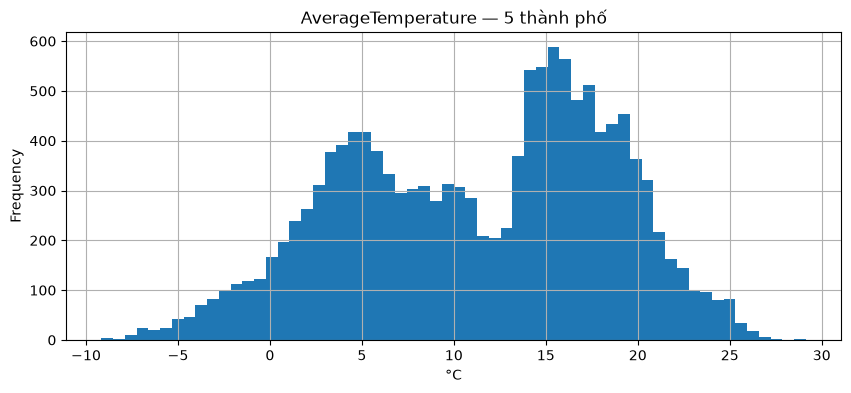

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
top5[TARGET].dropna().hist(bins=60, ax=ax)
ax.set_title("AverageTemperature — 5 thành phố")
ax.set_xlabel("°C")
ax.set_ylabel("Frequency")
plt.show()

## IX. Phân chia trách nhiệm SQL và Python

### PostgreSQL
- import dữ liệu lớn,
- index,
- filtering,
- aggregation,
- join 5 nguồn,
- tạo flat table.

### Python
- interpolation,
- statistical cleaning,
- EDA,
- feature engineering,
- modeling,
- deployment logic.

Lý do: SQL phù hợp thao tác tập dữ liệu lớn và quan hệ; Python thuận tiện cho thống kê, mô hình và trực quan.

## X. Kết luận Notebook 01

Sau khi chạy, phần kết luận phải ghi số liệu thực tế:

- số bảng, số dòng từng bảng;
- main table và grain;
- khoảng thời gian;
- missing và duplicate;
- các lỗi logic;
- chiến lược join 5 nguồn;
- kế hoạch PostgreSQL ở Notebook 02.

**Đầu ra:** dữ liệu đã được hiểu và sẵn sàng đưa vào PostgreSQL.